# OpenClassrooms - parcours Data Analyst Business Intelligence - P8

<!-- Styles globaux pour tous les titres -->
<style>
h1 {color: #E74C3C; font-size: 32px; font-weight: bold; border-bottom: 2px solid #E74C3C; padding-bottom: 5px;}
h2 {color: #3498DB; font-size: 28px; font-weight: bold; border-bottom: 1px solid #3498DB; padding-bottom: 3px;}
h3 {color: #2ECC71; font-size: 24px; font-weight: bold;}
h4 {color: #F39C12; font-size: 20px; font-weight: bold;}
h5 {color: #9B59B6; font-size: 18px; font-weight: bold;}
h6 {color: #7F8C8D; font-size: 16px; font-weight: bold;}
</style>

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

### 1.Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [1]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd, numpy as np
# N'oubliez pas d'avoir installé les librairies pandas, numpy et matplotlib via la commande pip

In [2]:
#On importe les données dans un dataframe
data_histo = pd.read_excel(r'C:\Users\Maela COLLONG\OneDrive - CATALYS CONSEIL\FORMATION DATA\Module 8\TELECHARGEMENTS\PAQUET 1\historique_immobilier_paris_2017_2021_vdef2.xlsx')
data_histo.head()

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


Attention, si l'opération ci-dessus ne marche pas, il se peut que le package "openpyxl" ne soit pas présent sur votre ordinateur. Si c'est le cas vous pouvez l'installer en éxécutant la commande : pip install openpyxl ou conda install openpyxl.

In [3]:
#### (MC) Vérifier le nombre de lignes et de colonnes du dataframe

In [4]:
data_histo.shape

(26196, 9)

In [5]:
#On vérifie que le type des données attribué par pandas est cohérent
data_histo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26196 non-null  datetime64[ns]
 1   valeur_fonciere   26196 non-null  float64       
 2   adresse_numero    26196 non-null  int64         
 3   adresse_nom_voie  26196 non-null  object        
 4   code_postal       26196 non-null  int64         
 5   nom_commune       26196 non-null  object        
 6   code_type_local   26196 non-null  int64         
 7   type_local        26196 non-null  object        
 8   surface_reelle    26196 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8+ MB


### 2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [6]:
types_codes = data_histo[['type_local', 'code_type_local']].drop_duplicates()

# Construire une chaîne lisible
message = ", ".join([f"{row['type_local']} ({row['code_type_local']})" for _, row in types_codes.iterrows()])
print('la liste des différents types de biens immobiliers que nous avons dans les données est :',message)


la liste des différents types de biens immobiliers que nous avons dans les données est : Appartement (2), Local industriel. commercial ou assimilé (4)


On observe qu'il y a ? types de biens, et que leurs codes types sont ?. => MC : réponse fournie ci-dessus

### 3. Nombre de transactions

In [7]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
nb_transactions = data_histo['date_mutation'].count()
nb_appartements = data_histo[data_histo['code_type_local'] == 2].shape[0]
nb_commerce = data_histo[data_histo['code_type_local'] == 4].shape[0]
print('le nombre de transactions dans les données est :', nb_transactions)
print('le nombre de transactions pour les appartements dans les données est ',nb_appartements)
print('le nombre de transactions pour les locaux commerciaux dans les données est ',nb_commerce)

le nombre de transactions dans les données est : 26196
le nombre de transactions pour les appartements dans les données est  24353
le nombre de transactions pour les locaux commerciaux dans les données est  1843


### 4. interval de l'historique des données

In [8]:
#On vérifie également la plage de l'historique disponible
date_debut = data_histo['date_mutation'].min()
date_fin = data_histo['date_mutation'].max()
print('la première date de transaction dans les données est le ', date_debut)
print('la dernière date de transaction dans les données est le ', date_fin)

la première date de transaction dans les données est le  2017-01-02 00:00:00
la dernière date de transaction dans les données est le  2021-12-31 00:00:00


## Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [9]:
# Calcul de la colonne
data_histo['prix_m2']=data_histo['valeur_fonciere']/data_histo['surface_reelle']

Maintenant, analysons les appartements.

### 5. Evolution du prix au metre carré des appartements dans Paris

In [10]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps
data_histo_appart = data_histo.drop(columns=['adresse_numero', 'adresse_nom_voie','type_local'])
data_histo_appart = data_histo_appart[data_histo_appart['code_type_local'] == 2]
data_histo_appart.head()

,date_mutation,valeur_fonciere,code_postal,nom_commune,code_type_local,surface_reelle,prix_m2
0,2017-01-03,5.505597e+05,75003,Paris 3e Arrondissement,2,50,11011.193562
1,2017-01-12,1.576492e+06,75008,Paris 8e Arrondissement,2,163,9671.732877
2,2017-01-10,6.577574e+05,75008,Paris 8e Arrondissement,2,66,9966.020548
3,2017-01-10,2.500868e+05,75003,Paris 3e Arrondissement,2,22,11367.582877
4,2017-01-13,1.762667e+05,75001,Paris 1er Arrondissement,2,15,11751.113836


In [11]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée
data_histo_appart['annee'] = pd.to_datetime(data_histo_appart['date_mutation']).dt.year
data_group_appart = data_histo_appart.groupby(['annee']).agg(prix_m2_moyen=('prix_m2','mean'))
display(data_group_appart)

#Reset de l'index
data_group_appart = data_group_appart.reset_index()

,prix_m2_moyen
annee,
2017,9492.859195
2018,10031.403432
2019,10562.712581
2020,10674.872650
2021,10455.600126


On constate sur la moyenne des prix de vente des appartements à Paris que ? <br>
    => Le prix au mètre carré augmente au fur et à mesure des années <br>
Nous allons créer un graphique pour mieux le visualiser.

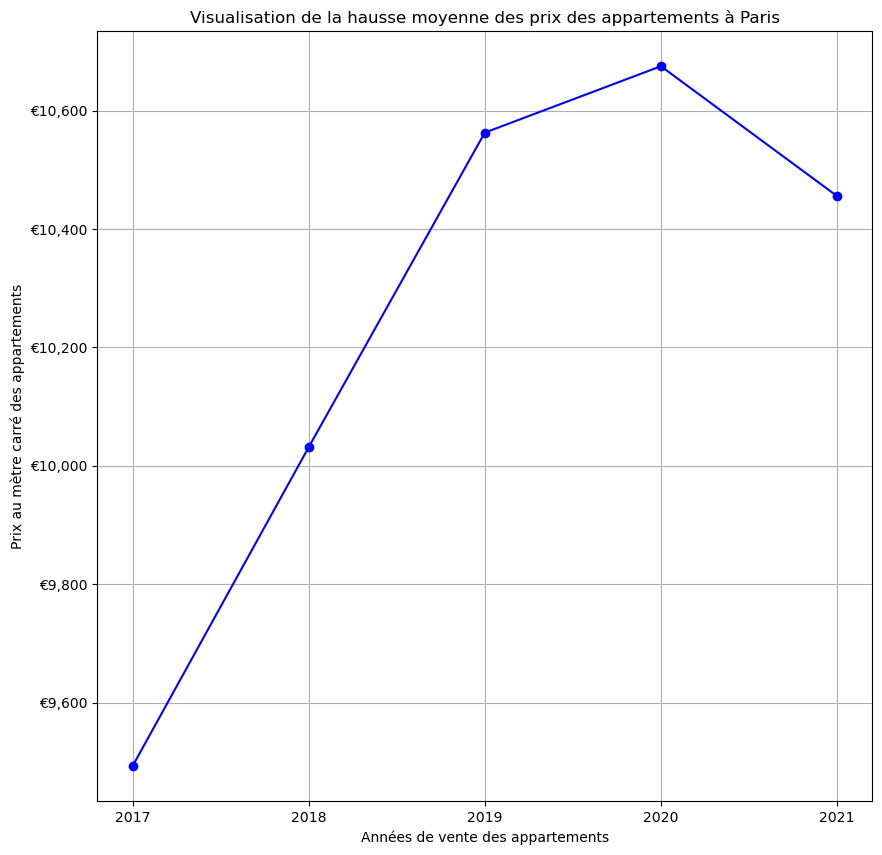

In [12]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 10))
plt.plot(data_group_appart['annee'], data_group_appart['prix_m2_moyen'], marker='o', color='blue')

plt.xlabel('Années de vente des appartements')
plt.ylabel('Prix au mètre carré des appartements')

# Formatter pour ajouter le symbole €
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.grid()
plt.title('Visualisation de la hausse moyenne des prix des appartements à Paris')

# Adapter automatiquement le nombre de ticks x
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))

plt.show()


### 6. Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [13]:
#Liste des codes postaux dans nos données.
list_cp = data_histo_appart['code_postal'].unique()
print("La liste des codes postaux mentionnés est : ",list_cp)
nb_cp_unique = data_histo_appart['code_postal'].nunique()
print("Le nombre de codes postaux différents est de : ",nb_cp_unique)

La liste des codes postaux mentionnés est :  [75003 75008 75001 75006 75005 75007 75010 75009 75011 75012 75013 75014
 75015 75016 75017 75018 75020 75019 75004 75002]
Le nombre de codes postaux différents est de :  20


### Créeons un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement


In [14]:
# Filtre de la base de données historique sur les appartements situés dans le 1er arrondissement uniquement
data_appart_75001 = data_histo_appart.loc[(data_histo_appart['code_type_local'] == 2) & (data_histo_appart['code_postal'] == 75001)]
data_group_appart75001 = (data_appart_75001.groupby(['annee']).agg(surface_moyenne = ('surface_reelle','mean'), prix_vente_moyen = ('valeur_fonciere','mean'), prix_m2_moyen=('prix_m2','mean')).reset_index())
print(data_group_appart75001)

   annee  surface_moyenne  prix_vente_moyen  prix_m2_moyen
0   2017        45.241379     530392.410096   11762.706289
1   2018        46.010204     581390.365711   12621.226146
2   2019        34.307692     454606.244889   13269.256149
3   2020        44.871429     601204.893337   13405.991820
4   2021        47.777778     639321.076138   13379.498578


In [15]:
data_group_appart75001['annee'] = data_group_appart75001['annee'].astype(int)

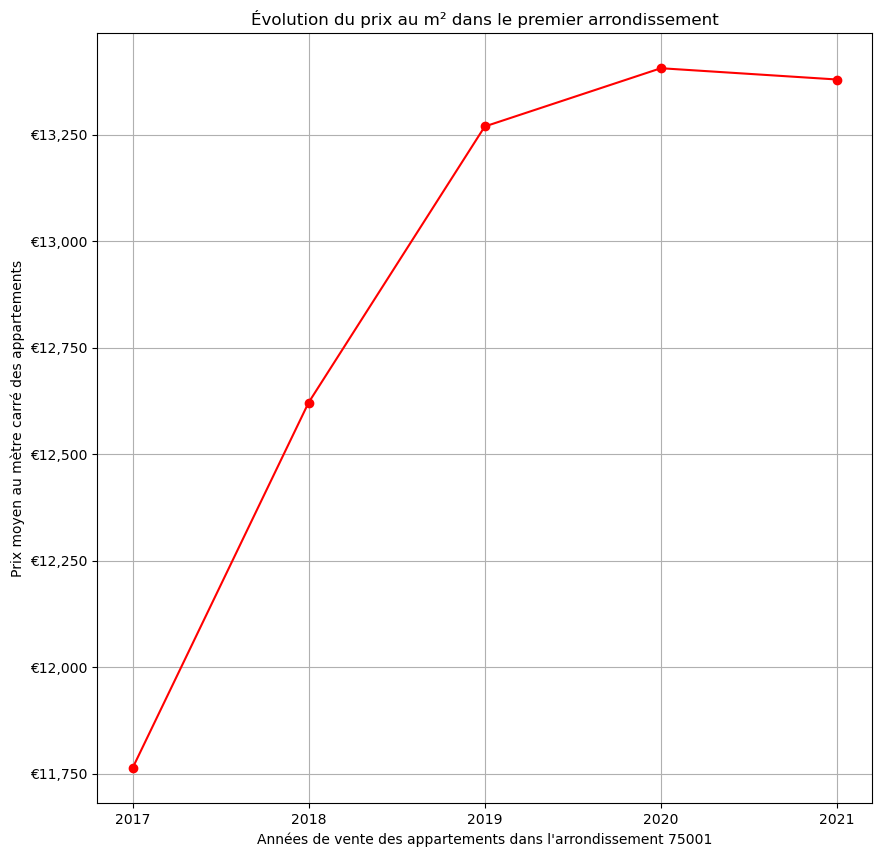

In [16]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 10))
plt.plot(data_group_appart75001['annee'], data_group_appart75001['prix_m2_moyen'], color='red', marker='o')

plt.xlabel("Années de vente des appartements dans l'arrondissement 75001")
plt.ylabel('Prix moyen au mètre carré des appartements')

# Formatter pour ajouter le symbole €
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.grid()
plt.title('Évolution du prix au m² dans le premier arrondissement')

# Adapter automatiquement les ticks x
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))

plt.show()


In [17]:
# Filtre de la base de données historique sur les appartements

data_group_appart_arr = (data_histo_appart.groupby(['annee','code_postal']).agg(surface_moyenne = ('surface_reelle','mean'), prix_vente_moyen = ('valeur_fonciere','mean'), prix_m2_moyen=('prix_m2','mean')).reset_index())
print(data_group_appart_arr)

    annee  code_postal  surface_moyenne  prix_vente_moyen  prix_m2_moyen
0    2017        75001        45.241379     530392.410096   11762.706289
1    2017        75002        43.093023     470308.377404   10920.126562
2    2017        75003        38.152047     445875.081014   11679.818729
3    2017        75004        40.935185     507122.253579   12407.227522
4    2017        75005        39.048077     440921.988442   11306.752404
..    ...          ...              ...               ...            ...
95   2021        75016        67.947945     732964.137887   10790.307817
96   2021        75017        46.781457     485246.571168   10372.368746
97   2021        75018        37.656947     364055.847980    9665.640629
98   2021        75019        38.260870     337972.960872    8828.586057
99   2021        75020        37.385455     340528.706134    9114.398249

[100 rows x 5 columns]


Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

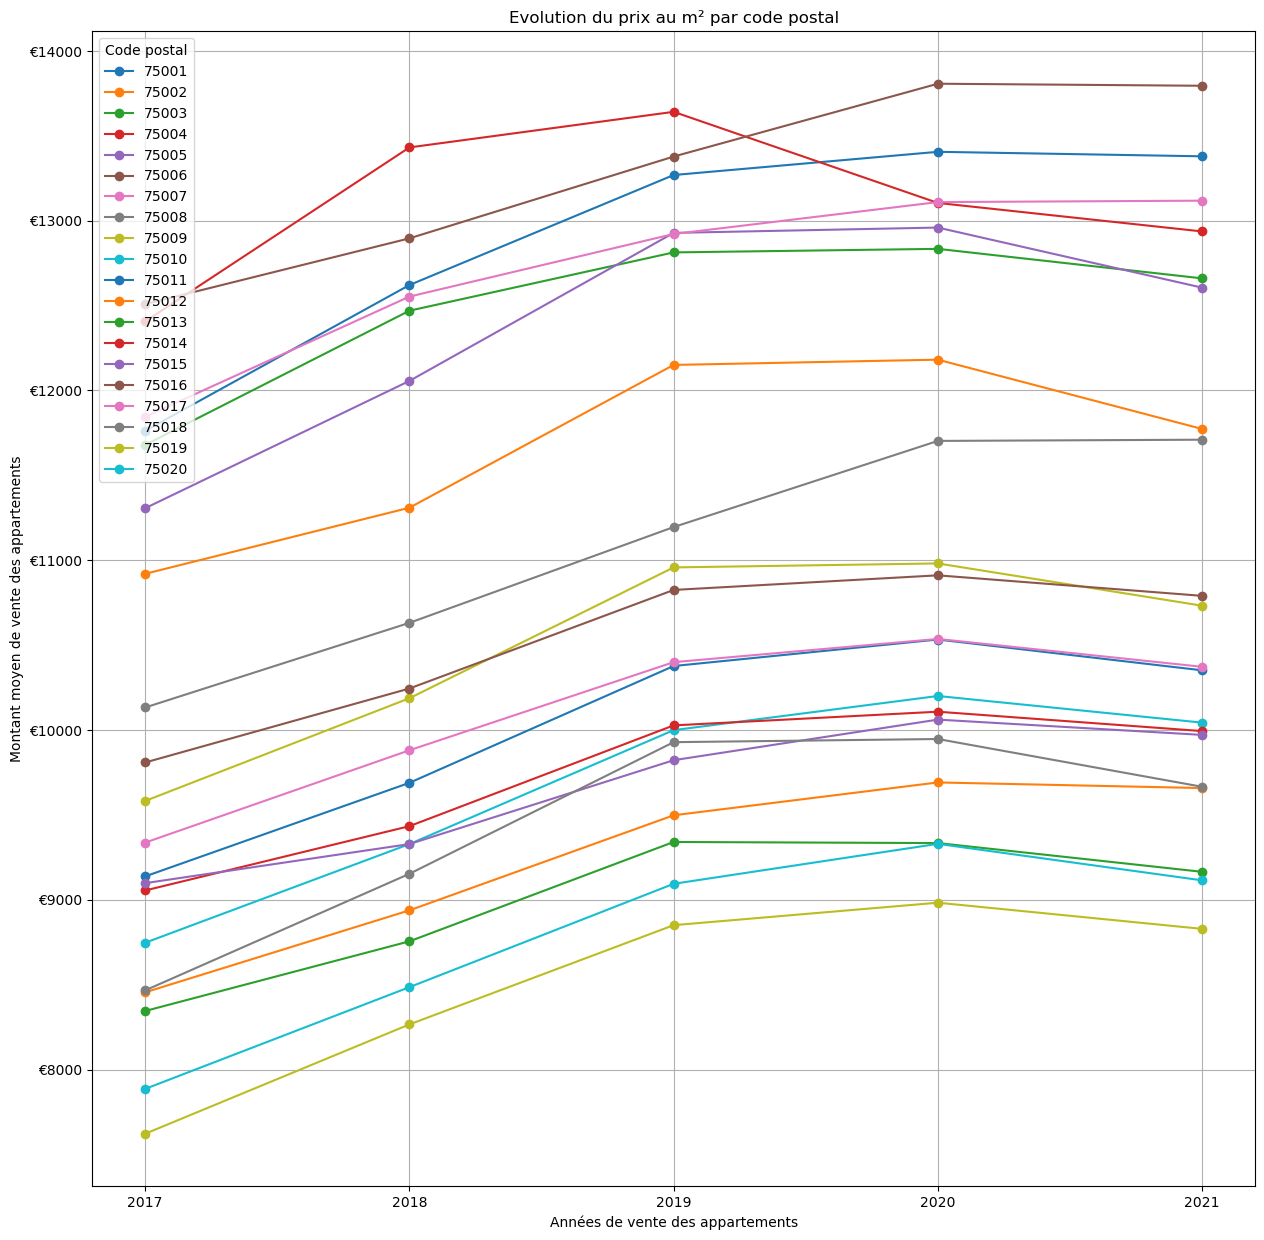

In [18]:
# Intervalle historique 
interval_historique = [2017, 2018, 2019, 2020, 2021]

# Pivot : codes postaux en colonnes, années en index
df_pivot = data_group_appart_arr.pivot(index='annee', columns='code_postal', values='prix_m2_moyen')

# Réindexer pour garder exactement l'ordre et les années souhaitées
df_pivot = df_pivot.reindex(interval_historique)

plt.figure(figsize=(15,15))

# Tracer toutes les lignes automatiquement
df_pivot.plot(marker='o', ax=plt.gca())

plt.xlabel('Années de vente des appartements')
plt.ylabel('Montant moyen de vente des appartements')
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution du prix au m² par code postal')
plt.legend(title='Code postal', loc='upper left')

# Forcer les ticks x exactement sur les années
plt.xticks(ticks=interval_historique)

plt.show()



On observe que globalement que ? => PIC jusqu'en 2019, augmentation en 2019 plus modérée sauf pour 4e arrondissement qui baisse puis baisse pour tous à partir de 2020

### 7. Prix au metre carré par transaction dans un arrondissement

In [19]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
Nb_transactions75006 = data_histo_appart.loc[data_histo_appart['code_postal'] == 75006, 'prix_m2'].count()

print(Nb_transactions75006)

709


In [20]:
## Comparaison du nombre de transations toute année confondue sur chacun des arrondissements
data_nb_transactions = data_histo_appart.groupby(['code_postal']).agg(nb_transactions=('prix_m2','count'))
display(data_nb_transactions)
#Reset de l'index
data_nb_trans = data_nb_transactions.reset_index()

,nb_transactions
code_postal,
75001,409
75002,666
75003,784
75004,548
75005,829
75006,709
75007,607
75008,628
75009,969


In [21]:
## Focus sur le 6ème arrondissement : nombre de transactions par année
data_appart_75006 = data_histo_appart.loc[(data_histo_appart['code_type_local'] == 2) & (data_histo_appart['code_postal'] == 75006)]
data_nb_transactions75006bis = data_appart_75006.groupby(['annee']).agg(nb_transactions=('prix_m2','count'))
                                
display(data_nb_transactions75006bis)
#Reset de l'index
data_nb_transactions75006bis = data_nb_transactions75006bis.reset_index()

,nb_transactions
annee,
2017,198
2018,175
2019,123
2020,108
2021,105


On constate que ?
    => Le 6ème arrondissement est l'un des arrondissements où il y a le moins de transactions et que ce nombre tend à diminuer d'année en année


Affichons l'historique des transactions pour visualiser la dispersion des données :

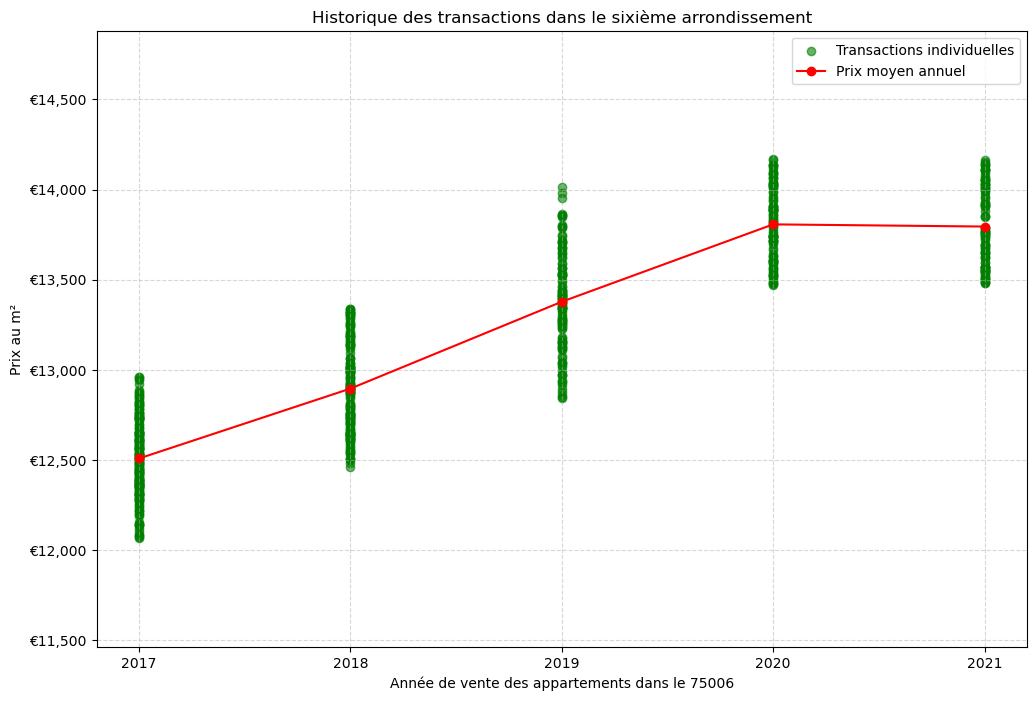

In [22]:

# Filtrer les transactions individuelles pour le 75006
data_75006 = data_histo_appart.loc[data_histo_appart['code_postal'] == 75006].copy()

plt.figure(figsize=(12, 8))

# Scatter plot des transactions individuelles
plt.scatter(data_75006['annee'], data_75006['prix_m2'], color='green', alpha=0.6, label='Transactions individuelles')

# Calculer le prix moyen par année pour afficher la tendance
stats_annee = data_75006.groupby('annee')['prix_m2'].mean().reset_index()
plt.plot(stats_annee['annee'], stats_annee['prix_m2'], color='red', marker='o', label='Prix moyen annuel')

plt.xlabel("Année de vente des appartements dans le 75006")
plt.ylabel('Prix au m²')

# Formatter pour le symbole €
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

plt.grid(which='both', linestyle='--', alpha=0.5)
plt.title('Historique des transactions dans le sixième arrondissement')
plt.legend()

# Axe y avec un peu de marge
y_min = data_75006['prix_m2'].min() * 0.95
y_max = data_75006['prix_m2'].max() * 1.05
plt.ylim(y_min, y_max)

# Ticks x entiers
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()


<span style="padding:10px;background-color:#faa18f"> 
On observe que ?
</span>

On observe qu’au fil des années, la fourchette des prix au m² s’élève : à la fois les prix les plus élevés et les prix les plus bas augmentent, ce qui reflète une tendance générale à la hausse du marché immobilier dans le sixième arrondissement.

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

### 8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson 

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [23]:
#On calcule la corrélation de Spearman /// correction : pearson
from scipy import stats

#Données
x = data_75006['annee']
y = data_75006['prix_m2']


# Calcul de la corrélation de Pearson
r, p_value = stats.pearsonr(x, y)

print("Coefficient de corrélation r :", r)
print("p-value :", p_value)


Coefficient de corrélation r : 0.891624211404072
p-value : 1.7235314882854273e-245


"Le coefficient de corrélation est de ? avec une pvalue de ? donc nous pouvons confirmer la corrélation."

<span style="padding:10px;background-color:#cfcfcf"> 
Le coefficient de corrélation est de 0,891 donc proche de 1 et avec une pvalue de 1,72e-245 donc en dessous de 0,05 ce qui confirme une relation forte
</span>


### 9. Vérification de la relation entre la valeur fonciere et la surface

In [24]:
x = data_histo_appart['surface_reelle']
y = data_histo_appart['valeur_fonciere']

# Calcul de la corrélation de Pearson
r, p_value = stats.pearsonr(x, y)

print("Coefficient de corrélation r :", r)
print("p-value :", p_value)

Coefficient de corrélation r : 0.9801182734228691
p-value : 0.0


Le coefficient de corrélation est de ? avec une pvalue de ?. La relation est donc confirmée.

<span style="padding:10px;background-color:#cfcfcf"> 
Le coefficient de corrélation est de 0,980 donc proche de 1 et avec une pvalue de 0,00 donc en dessous de 0,05 ce qui confirme une relation forte
</span>


Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 10. Analyse des locaux industriels, commerciaux et assimilés 

In [25]:
#On crée un dataset qui ne contient que les locaux commerciaux
data_histo_commerce = data_histo.drop(columns=['adresse_numero', 'adresse_nom_voie','type_local'])
data_histo_commerce = data_histo_commerce[data_histo_commerce['code_type_local'] == 4]
data_histo_commerce.head()

,date_mutation,valeur_fonciere,code_postal,nom_commune,code_type_local,surface_reelle,prix_m2
18,2017-02-01,3.113277e+06,75003,Paris 3e Arrondissement,4,250,12453.109192
29,2017-02-17,1.164375e+06,75003,Paris 3e Arrondissement,4,95,12256.581685
34,2017-02-20,3.802522e+05,75003,Paris 3e Arrondissement,4,31,12266.199603
91,2017-03-09,3.623842e+05,75001,Paris 1er Arrondissement,4,29,12496.006027
109,2017-03-29,3.159072e+05,75003,Paris 3e Arrondissement,4,25,12636.289027


In [26]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année
data_histo_commerce['annee'] = pd.to_datetime(data_histo_commerce['date_mutation']).dt.year
data_group_commerce = data_histo_commerce.groupby(['annee']).agg(prix_m2_moyen=('prix_m2','mean'))
display(data_group_commerce)

#Reset index
data_group_commerce = data_group_commerce.reset_index()

,prix_m2_moyen
annee,
2017,10949.909217
2018,11569.499180
2019,11960.132050
2020,11966.470204
2021,12006.488691


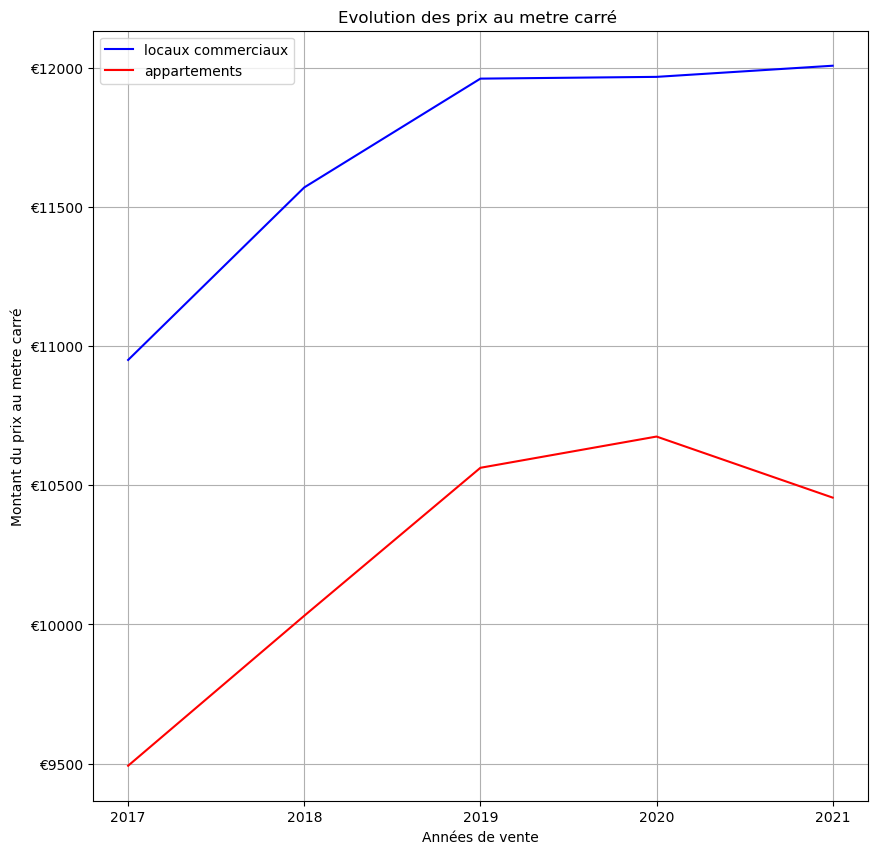

In [27]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(10,10))
y = data_group_commerce['prix_m2_moyen']
y2 = data_group_appart['prix_m2_moyen']
plt.plot(['2017','2018','2019','2020','2021'],y,label='locaux commerciaux',color='blue')
plt.plot(['2017','2018','2019','2020','2021'],y2,label='appartements',color='red')
plt.xlabel('Années de vente')
plt.ylabel('Montant du prix au metre carré')
plt.legend()
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()
plt.title('Evolution des prix au metre carré ')
plt.show()

Le prix au metre carré des locaux commerciaux est ?

In [28]:
moy_prix_commerce = round(data_group_commerce['prix_m2_moyen'].mean(),2)

print(f'Le prix au metre carré des locaux commerciaux est de {moy_prix_commerce}€')

Le prix au metre carré des locaux commerciaux est de 11690.5€


Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont : 
- la surface du bien immobilier,
- la date considérée, 
- la localisation (code_postal), 
- le type de bien.

# Milestone 2 - Entraînement de l'algorithme

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

## 1. Préparation des données

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [29]:
# On veille à ne sélectionner que les colonnes utiles
data_histo_m2 = data_histo[['code_postal','type_local','valeur_fonciere','surface_reelle','date_mutation']]
data_histo_m2_2 = data_histo_m2.rename(columns={'surface_reelle':'surface'})
data_histo_encoded = pd.get_dummies(data_histo_m2_2,columns=["code_postal", "type_local"],dtype =int)
data_histo_encoded.filter(like="code_postal").head()
data_histo_encoded.head()

,valeur_fonciere,surface,date_mutation,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,...,code_postal_75013,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,5.505597e+05,50,2017-01-03,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1.576492e+06,163,2017-01-12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,6.577574e+05,66,2017-01-10,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2.500868e+05,22,2017-01-10,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1.762667e+05,15,2017-01-13,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


Note MC : Les variables issues du one-hot encoding sont de type booléen (True/False), ce qui est équivalent à un encodage binaire (0/1) et pleinement compatible avec la régression linéaire.

## 2. Séparation des données : test / entraînement

MEMO : Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont : 
- la surface du bien immobilier => surface_reelle 
- la date considérée => date_mutation
- la localisation (code_postal) => Déclinaison pour chacun des codes postaux
- le type de bien => type_local  => Déclinaison par type


On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [30]:
data_histo_encoded.columns

Index(['valeur_fonciere', 'surface', 'date_mutation', 'code_postal_75001',
       'code_postal_75002', 'code_postal_75003', 'code_postal_75004',
       'code_postal_75005', 'code_postal_75006', 'code_postal_75007',
       'code_postal_75008', 'code_postal_75009', 'code_postal_75010',
       'code_postal_75011', 'code_postal_75012', 'code_postal_75013',
       'code_postal_75014', 'code_postal_75015', 'code_postal_75016',
       'code_postal_75017', 'code_postal_75018', 'code_postal_75019',
       'code_postal_75020', 'type_local_Appartement',
       'type_local_Local industriel. commercial ou assimilé'],
      dtype='object')

In [31]:
# conversion de la date en valeurs numérique int64

data_histo_encoded['timestamp'] = data_histo_encoded['date_mutation'].astype('datetime64[s]').astype('int64')/10**9

In [32]:
data_histo_encoded.drop(['date_mutation'],axis='columns',inplace=True)

In [33]:
data_histo_encoded.head()

,valeur_fonciere,surface,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,code_postal_75008,...,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé,timestamp
0,5.505597e+05,50,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.483402
1,1.576492e+06,163,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,1.484179
2,6.577574e+05,66,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,1.484006
3,2.500868e+05,22,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.484006
4,1.762667e+05,15,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.484266


Note : La colonne ne contient plus des dates mais le nombre de secondes écoulées depuis le 01/01/1970.
        C’est un entier plus petit et plus facile à utiliser pour des calculs ou des modèles.

In [34]:
from sklearn.model_selection import train_test_split

# Variables prédictives
X = data_histo_encoded.drop('valeur_fonciere', axis=1)

# Variable cible : La valeur y à trouver est la valeur foncière
y = data_histo_encoded.valeur_fonciere

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [35]:
#conversion des données en str


Pourquoi repasser en str ??? alors que le modèle doit s'entraîner sur des données numériques ?

In [36]:
from sklearn.linear_model import LinearRegression

#On entraîne l'algorithme ci-dessous et on effectue la prédiction
reg=LinearRegression().fit(X_train, y_train)

# et on effectue la prédiction
y_pred_test = reg.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
print(f"RMSE : {mean_squared_error(y_test, y_pred_test)}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_test)}")

RMSE : 6121458968.895091
MAPE : 0.0952922066319762


Notre algorithme fait donc 9,5% d'erreur en moyenne sur la prédiction de la valeur foncière.

## 3. Mes conclusions sur ce résultat et comment j'aurais pu aller plus loin :
=> voir support de présentation


# Milestone 3 - Prédiction définitive pour le client 

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez. 

In [38]:
#On importe les données dans un dataframe
data_portefeuille = pd.read_excel(r"C:\Users\Maela COLLONG\OneDrive - CATALYS CONSEIL\FORMATION DATA\Module 8\TELECHARGEMENTS\PAQUET 1\portefeuille_actifs+(3).xlsx", sheet_name='Portefeuille actifs')

print(data_portefeuille.dtypes)

print(data_portefeuille.shape)

display(data_portefeuille.head(2))

adresse_numero                 int64
adresse_nom_voie              object
code_postal                    int64
code_commune                   int64
nom_commune                   object
surface_carrez               float64
code_type_local                int64
type_local                    object
surface_reelle_bati            int64
nombre_pieces_principales      int64
longitude                    float64
latitude                     float64
dtype: object
(275, 12)


,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [39]:
data_portefeuille_m3 = data_portefeuille[['code_postal','type_local','surface_reelle_bati']]
data_portefeuille_m3_2 = data_portefeuille_m3.rename(columns={'surface_reelle_bati':'surface'})

In [40]:
data_portefeuille_m3_2.head(5)

,code_postal,type_local,surface
0,75001,Appartement,25
1,75003,Appartement,22
2,75003,Appartement,65
3,75008,Appartement,74
4,75008,Appartement,22


In [41]:
#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles
data_portefeuille_encoded = pd.get_dummies(data_portefeuille_m3_2,columns=["code_postal", "type_local"],dtype =int)
data_portefeuille_encoded.filter(like="code_postal").head()

#On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction
import datetime as dt
data_portefeuille_encoded['timestamp'] = int(dt.datetime(2022, 12, 31).timestamp())/10**9


In [42]:
#Conversion du dataframe en str
data_portefeuille_encoded.head()

,surface,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,code_postal_75008,code_postal_75009,...,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé,timestamp
0,25,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.672441
1,22,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.672441
2,65,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.672441
3,74,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1.672441
4,22,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1.672441


In [43]:
# Colonnes utilisées pour l'entraînement
X_columns = X_train.columns  

# Réordonner et compléter les colonnes manquantes
for col in X_columns:
    if col not in data_portefeuille_encoded.columns:
        data_portefeuille_encoded[col] = 0  # ou une valeur par défaut appropriée

# Réordonner
data_portefeuille_encoded = data_portefeuille_encoded[X_columns]


Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [44]:
#On effectue la prédiction
y_pred_portefeuille = reg.predict(data_portefeuille_encoded)

#On vérifie les 10 premières valeurs
y_pred_portefeuille[:10]

array([431442.69547606, 368859.73636052, 827084.7044644 , 878983.19832372,
       324850.67875623, 463383.8086481 , 390172.52557466, 642452.47687867,
       139735.13090578, 141905.21390905])

In [45]:
#On effectue la prédiction
y_pred_portefeuille = reg.predict(data_portefeuille_encoded)

#On vérifie les 10 premières valeurs
data_portefeuille['valeur_fonciere_estimee'] = y_pred_portefeuille
display(data_portefeuille.head(10))

#Export des données au format csv
data_portefeuille.to_csv(r"C:\Users\Maela COLLONG\OneDrive - CATALYS CONSEIL\FORMATION DATA\Module 8\Portefeuille_prediction_projet8.csv", index=False, sep=";")

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude,valeur_fonciere_estimee
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227,431442.695476
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907,368859.736361
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318,827084.704464
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893,878983.198324
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490,324850.678756
5,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,33.40,2,Appartement,35,1,2.311643,48.875490,463383.808648
6,52,RUE DES GRAVILLIERS,75003,75103,Paris 3e Arrondissement,21.35,2,Appartement,24,2,2.355637,48.864366,390172.525575
7,208,RUE SAINT MAUR,75010,75110,Paris 10e Arrondissement,54.69,2,Appartement,60,3,2.371885,48.873209,642452.476879
8,142,RUE DE COURCELLES,75017,75117,Paris 17e Arrondissement,9.30,2,Appartement,11,1,2.300373,48.882505,139735.130906
9,52,RUE LAMARCK,75018,75118,Paris 18e Arrondissement,12.88,2,Appartement,13,1,2.342134,48.889431,141905.213909


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [46]:
#Valorisation du portefeuille sur le segment des particuliers
valorisation_appart = round(data_portefeuille.loc[data_portefeuille['code_type_local']==2,'valeur_fonciere_estimee'].sum()/1000000,2)
print(f'la valorisation du segment particulier est (en millions deuros):{valorisation_appart}M€')


la valorisation du segment particulier est (en millions deuros):71.05M€


In [47]:
#Valorisation du portefeuille sur le segment corporate
valorisation_commerce = round(data_portefeuille.loc[data_portefeuille['code_type_local']==4,'valeur_fonciere_estimee'].sum()/1000000,2)
print(f'la valorisation du segment particulier est (en millions deuros):{valorisation_commerce}M€')

la valorisation du segment particulier est (en millions deuros):97.97M€


Mes conclusions sur le segment avec la plus grande valorisation et sur les limites de cette estimation :
- ?
- ?

# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [48]:
#On importe les données dans un dataframe
data_echantillon = pd.read_excel(r"C:\Users\Maela COLLONG\OneDrive - CATALYS CONSEIL\FORMATION DATA\Module 8\TELECHARGEMENTS\PAQUET 2\echantillon_a_classer2.xlsx")

print(data_echantillon.dtypes)

print(data_echantillon.shape)

display(data_echantillon.head(2))

valeur_fonciere    float64
code_postal          int64
nom_commune         object
surface_reelle       int64
dtype: object
(40, 4)


,valeur_fonciere,code_postal,nom_commune,surface_reelle
0,868687.083271,75019,Paris 19e Arrondissement,88
1,452050.762192,75019,Paris 19e Arrondissement,45


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [49]:
#Création de la colonne prix m²
data_echantillon['prix_m2'] = round(data_echantillon['valeur_fonciere'] / data_echantillon['surface_reelle'],2)
display(data_echantillon.head())

,valeur_fonciere,code_postal,nom_commune,surface_reelle,prix_m2
0,868687.083271,75019,Paris 19e Arrondissement,88,9871.44
1,452050.762192,75019,Paris 19e Arrondissement,45,10045.57
2,193088.653587,75019,Paris 19e Arrondissement,21,9194.70
3,303012.549370,75019,Paris 19e Arrondissement,32,9469.14
4,149272.200110,75019,Paris 19e Arrondissement,20,7463.61


In [50]:
# création d'un dataframe dédié au kmeans
data_echantillon_m4 = data_echantillon['prix_m2']
display(data_echantillon_m4.head())

0     9871.44
1    10045.57
2     9194.70
3     9469.14
4     7463.61
Name: prix_m2, dtype: float64

Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [51]:
from sklearn.cluster import KMeans
X = data_echantillon_m4.values.reshape(-1,1)


kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

C:\Users\Maela COLLONG\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=2, random_state=0)

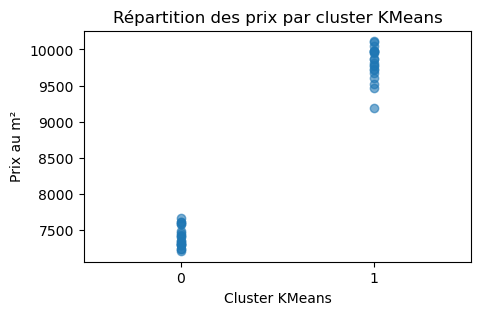

In [52]:
# On vérifie les données de la prédiction
data_cluster = pd.DataFrame({'prix_m2': data_echantillon_m4, 'label_kmeans': kmeans.labels_})
plt.figure(figsize=(5,3))
x = data_cluster['label_kmeans']
y = data_cluster['prix_m2']
plt.xlim(-0.5, 1.5)       # car 2 clusters : 0 et 1
plt.xticks([0, 1])
plt.scatter(x, y, alpha=0.6)  # alpha pour rendre les points transparents si chevauchement
plt.xlabel('Cluster KMeans')
plt.ylabel('Prix au m²')
plt.title('Répartition des prix par cluster KMeans')
plt.show()

In [53]:
#On affiche les résultats
data_cluster.groupby('label_kmeans')['prix_m2'].mean()


label_kmeans
0    7408.774
1    9806.924
Name: prix_m2, dtype: float64

Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement.

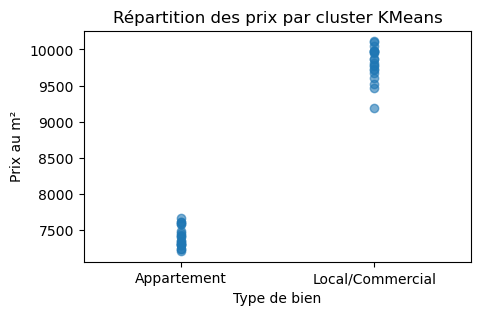

In [54]:
# Ajout d'une colonne explicite pour le type de bien
data_cluster['type_bien'] = data_cluster['label_kmeans'].replace({
    0: 'Appartement',
    1: 'Local industriel, commercial ou assimilé'
})

# Visualisation
plt.figure(figsize=(5,3))
x = data_cluster['label_kmeans']  # valeurs 0 et 1 pour l'axe X
y = data_cluster['prix_m2']
plt.xlim(-0.5, 1.5)       # car 2 clusters : 0 et 1
plt.xticks([0, 1], ['Appartement','Local/Commercial'])
plt.scatter(x, y, alpha=0.6)
plt.xlabel('Type de bien')
plt.ylabel('Prix au m²')
plt.title('Répartition des prix par cluster KMeans')
plt.show()


In [55]:
data_echantillon['type_local_kmean'] = data_cluster['type_bien']
display(data_echantillon.head(10))

,valeur_fonciere,code_postal,nom_commune,surface_reelle,prix_m2,type_local_kmean
0,868687.083271,75019,Paris 19e Arrondissement,88,9871.44,"Local industriel, commercial ou assimilé"
1,452050.762192,75019,Paris 19e Arrondissement,45,10045.57,"Local industriel, commercial ou assimilé"
2,193088.653587,75019,Paris 19e Arrondissement,21,9194.70,"Local industriel, commercial ou assimilé"
3,303012.549370,75019,Paris 19e Arrondissement,32,9469.14,"Local industriel, commercial ou assimilé"
4,149272.200110,75019,Paris 19e Arrondissement,20,7463.61,Appartement
5,179676.304545,75019,Paris 19e Arrondissement,18,9982.02,"Local industriel, commercial ou assimilé"
6,241856.569418,75019,Paris 19e Arrondissement,25,9674.26,"Local industriel, commercial ou assimilé"
7,462981.797149,75019,Paris 19e Arrondissement,63,7348.92,Appartement
8,518819.726233,75019,Paris 19e Arrondissement,53,9789.05,"Local industriel, commercial ou assimilé"
9,403670.310822,75019,Paris 19e Arrondissement,53,7616.42,Appartement


In [56]:
#Export des résultats vers un fichier excel
data_echantillon.to_excel(r"C:\Users\Maela COLLONG\OneDrive - CATALYS CONSEIL\FORMATION DATA\Module 8\Echantillon_valorise_projet8.xlsx", index=False)

# Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse et les limites de l'exercice :
- ?
- ?